## Elaborado por David Steven Garzon Rodriguez y Carlos Arturo Acevedo Santiago

* Imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
import sympy as sp
from scipy.integrate import solve_ivp

# Modelo que vamos a usar
![Modelo de depredador presa](resources/Modelo-depredador-presa.png)

* Clase escenario junto con sus atributos y metodos

In [5]:
class Escenario:
    def __init__(self, alpha = 2.0, beta = 1.5, gamma = 1.0, delta = 0.5, K = 2.5):
        #Parametros del sistema
        self.alpha = alpha
        self.beta = beta
        self.gamma = gamma
        self.delta = delta
        self.K = K
        
        #Simbolos algebraicos
        self.presas_symb, self.depredador_symb = sp.symbols('R F', real=True)
        
        #Ecuaciones del sistema
        self.ecuacion_presas = self.alpha * self.presas_symb * (1 - self.presas_symb / self.K) - self.beta * self.presas_symb * self.depredador_symb
        self.ecuacion_depredador = -self.gamma * self.depredador_symb + self.delta * self.presas_symb * self.depredador_symb
        
    def sistema_edo(self, tiempo, estado):
        R, F = estado
        dRdt = self.alpha * R * (1 - R / self.K) - self.beta * R * F
        dFdt = -self.gamma * F + self.delta * R * F
        return [dRdt, dFdt]
    
    def simular(self, poblacion_presas_inicial, poblacion_depredador_inicial, tiempo_final=16, paso=0.01):
        self.poblacion_presas_inicial = poblacion_presas_inicial
        self.poblacion_depredador_inicial = poblacion_depredador_inicial
        self.tiempo_final = tiempo_final
        self.paso = paso
        
        # Calcula la cantidad exacta de pasos
        num_puntos = int(tiempo_final / paso) + 1
        self.t_eval = np.linspace(0, tiempo_final, num_puntos)    
        
        solucion = solve_ivp(
            self.sistema_edo, 
            [0, tiempo_final], 
            [poblacion_presas_inicial, poblacion_depredador_inicial], 
            t_eval=self.t_eval, 
            method='RK45'
        )
        
        self.tiempo, self.poblacion_presas, self.poblacion_depredador = solucion.t, solucion.y[0], solucion.y[1]
        return self.tiempo, self.poblacion_presas, self.poblacion_depredador
    
    def calcular_puntos_equilibrio(self):
        puntos = sp.solve([self.ecuacion_presas, self.ecuacion_depredador], (self.presas_symb, self.depredador_symb), dict=True)
        
        matriz_jacobiana = sp.Matrix([self.ecuacion_presas, self.ecuacion_depredador]).jacobian([self.presas_symb, self.depredador_symb])
        
        resultados = []
        
        for p in puntos:
            R_eq = float(p[self.presas_symb])
            F_eq = float(p[self.depredador_symb])
            
            jacobiano_evaluado = matriz_jacobiana.subs({self.presas_symb: R_eq, self.depredador_symb: F_eq})
            
            autovalores_redondeados = {
                complex(round(float(sp.re(ev)), 2), round(float(sp.im(ev)), 2)): mult 
                for ev, mult in jacobiano_evaluado.eigenvals().items()
            }
            
            jacobiano_redondeado = [
                [round(float(sp.N(jacobiano_evaluado[i, j])), 2) for j in range(jacobiano_evaluado.cols)]
                for i in range(jacobiano_evaluado.rows)
            ]
            
            resultados.append({
                'punto_equilibrio': (round(R_eq, 2), round(F_eq, 2)),
                'jacobiano': jacobiano_redondeado,
                'autovalores': autovalores_redondeados
            })
            
        return resultados
        

    def graficar_series(self):
        plt.figure(figsize=(10, 4))
        plt.plot(self.tiempo, self.poblacion_presas, label=f'Presa (R0 = {self.poblacion_presas_inicial})', color='blue')
        plt.plot(self.tiempo, self.poblacion_depredador, label=f'Depredador (F0 = {self.poblacion_depredador_inicial})', color='orange')
        plt.xlabel("Tiempo (t)")
        plt.ylabel("Población")
        plt.title("Evolución temporal de las poblaciones")
        plt.legend()
        plt.grid(True)
        plt.show()
    
    def retrato_de_fase(self):
        dx = np.diff(self.poblacion_presas)
        dy = np.diff(self.poblacion_depredador)
        paso = 300 
        xs = self.poblacion_presas[paso::paso]
        ys = self.poblacion_depredador[paso::paso]
        dxs = dx[paso::paso]
        dys = dy[paso::paso]

        r_0 = round(self.poblacion_presas_inicial, 4)
        f_0 = round(self.poblacion_depredador_inicial, 4)
        
        plt.plot(self.poblacion_presas, self.poblacion_depredador, label=f'R_0 = {r_0} y F_0 = {f_0}')
        plt.quiver(xs, ys, dxs, dys, angles="xy", scale=0.3, width=0.005, zorder=0)
    

* Punto de equilibrio y autovalores para este ejemplo

In [6]:
modelo = Escenario(alpha=2.0, beta=1.5, gamma=1.0, delta=0.8, K=2.5)

modelo.simular(poblacion_presas_inicial=1.0, poblacion_depredador_inicial=0.5, tiempo_final=16, paso=0.01)

equilibrios = modelo.calcular_puntos_equilibrio()

print("Puntos de equilibrio y sus autovalores:")
for eq in equilibrios:
    print(f"Punto de equilibrio: {eq['punto_equilibrio']}")
    print(f"Matriz Jacobiana: {eq['jacobiano']}")
    print(f"Autovalores: {eq['autovalores']}\n")
    

Puntos de equilibrio y sus autovalores:
Punto de equilibrio: (0.0, 0.0)
Matriz Jacobiana: [[2.0, 0.0], [0.0, -1.0]]
Autovalores: {(2+0j): 1, (-1+0j): 1}

Punto de equilibrio: (2.5, 0.0)
Matriz Jacobiana: [[-2.0, -3.75], [0.0, 1.0]]
Autovalores: {(-2+0j): 1, (1+0j): 1}

Punto de equilibrio: (1.25, 0.67)
Matriz Jacobiana: [[-1.0, -1.88], [0.53, 0.0]]
Autovalores: {(-0.5-0.87j): 1, (-0.5+0.87j): 1}



In [7]:
caso1 = Escenario(alpha=2.0, beta=1.5, gamma=1.0, delta=0.8, K=2.5)
caso1.simular(poblacion_presas_inicial=0.2, poblacion_depredador_inicial=1.5, tiempo_final=16, paso=0.01)

caso2 = Escenario(alpha=2.0, beta=1.5, gamma=1.0, delta=0.8, K=2.5)
caso2.simular(poblacion_presas_inicial=2.2, poblacion_depredador_inicial=2.0, tiempo_final=16, paso=0.01)

caso3 = Escenario(alpha=2.0, beta=1.5, gamma=1.0, delta=0.8, K=2.5)
caso3.simular(poblacion_presas_inicial=2.1, poblacion_depredador_inicial=0.8, tiempo_final=16, paso=0.01)

caso4 = Escenario(alpha=2.0, beta=1.5, gamma=1.0, delta=0.8, K=2.5)
caso4.simular(poblacion_presas_inicial=5/4, poblacion_depredador_inicial=6/9, tiempo_final=16, paso=0.01)

(array([0.000e+00, 1.000e-02, 2.000e-02, ..., 1.598e+01, 1.599e+01,
        1.600e+01], shape=(1601,)),
 array([1.25, 1.25, 1.25, ..., 1.25, 1.25, 1.25], shape=(1601,)),
 array([0.66666667, 0.66666667, 0.66666667, ..., 0.66666667, 0.66666667,
        0.66666667], shape=(1601,)))

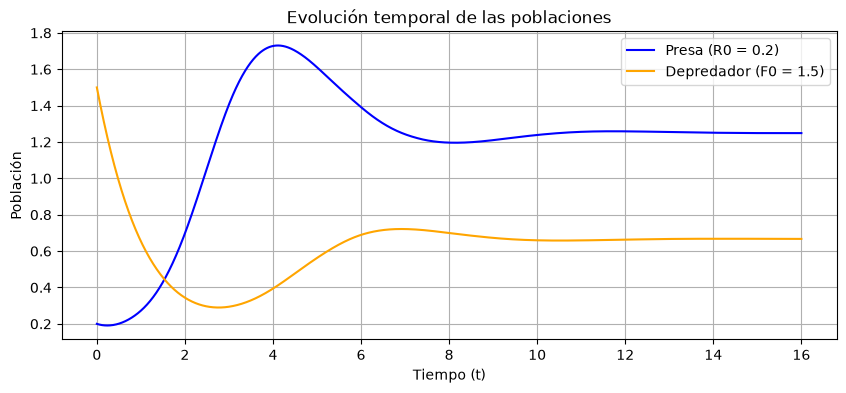

In [8]:
caso1.graficar_series()

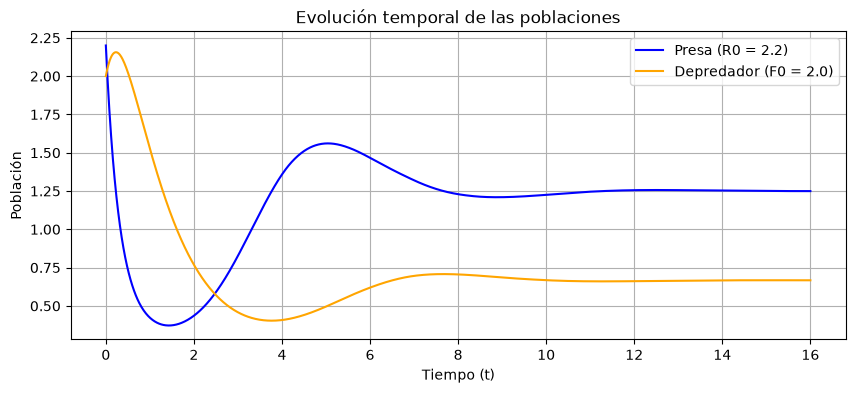

In [9]:
caso2.graficar_series()

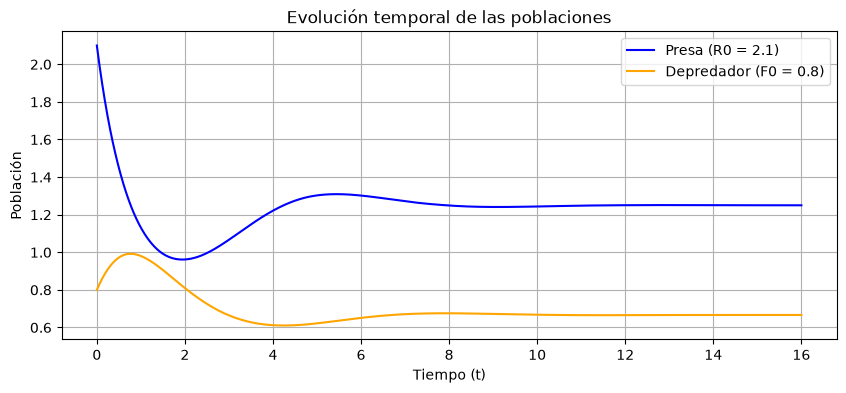

In [10]:
caso3.graficar_series()

* Muestras para el retrato de fase

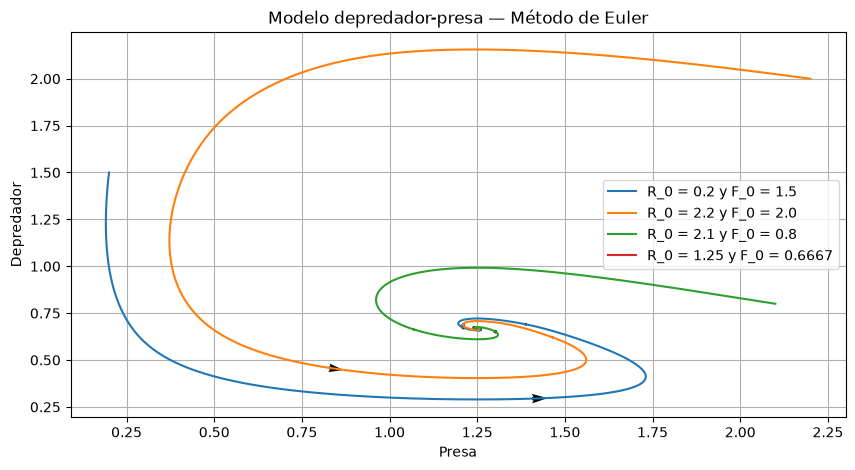

In [11]:
plt.figure(figsize=(10, 5))

caso1.retrato_de_fase(); caso2.retrato_de_fase(); caso3.retrato_de_fase(); caso4.retrato_de_fase()

plt.xlabel("Presa")
plt.ylabel("Depredador")
plt.title("Modelo depredador-presa — Método de Euler")
plt.legend()
plt.grid()

plt.show()